In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
from sympy import lambdify 
from sympy.abc import x, y, s


(0.0, 1.0)

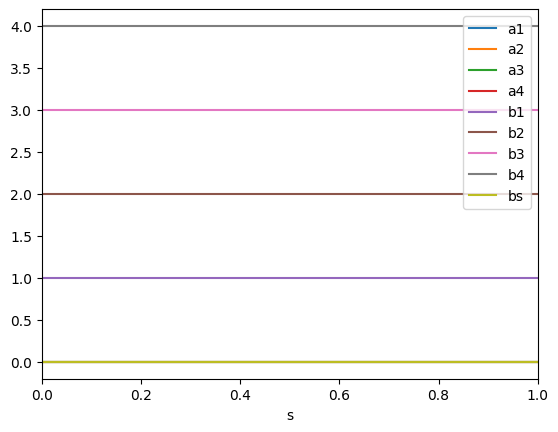

In [25]:
#start from multipole coeefficients a_n(s)=a1,a2,... and b_n(s)
a_coeffs = [0, 0, 0, 0]
b_coeffs = [1,2,3, 4]
#get scalar potential
expansion=bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs)
expansion.plot_components()
plt.xlabel('s')
plt.xlim((0,1))

/home/fmarcoli/bpmeth/src/bpmeth/generate_expansion.py:94: UserWarning: More terms are needed in the expansion for aperture 0.05m, the laplacian is -2.22044604925031E-17
  warnings.warn(f"More terms are needed in the expansion for aperture {apperture}m, the laplacian is {laplval}")


Scalar potential phi(x,y,s): -y**3*(24*x + 18)/36 + y*(4*x**3 + 9*x**2 + 12*x + 6)/6
Scalar potential phi at (0.4,0.2,0.5): 0.4104000000000001


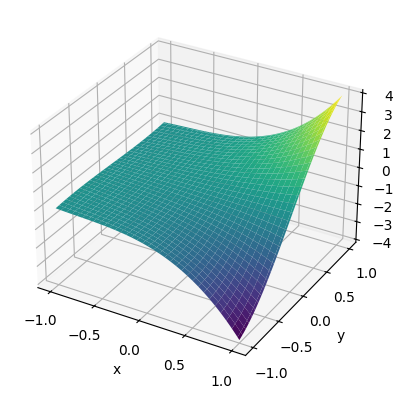

In [26]:
phi=expansion.get_phi()
print("Scalar potential phi(x,y,s):", phi)

XYS=(x,y,s)#symbolic expressions

phi_func = lambdify(XYS, phi, 'numpy')#from symbolic to numerical function
print("Scalar potential phi at (0.4,0.2,0.5):", phi_func(0.4,0.2,0.5))
#define x,y,s axes to convert the symbolic expression of phi into a numerical array
xa= np.linspace(-1,1,101) 
ya=np.linspace(-1,1,101)
sa=np.linspace(-1,1,101)
#make a 3d plot of phi as a function of x and y for a fixed s
X, Y = np.meshgrid(xa, ya)
P = phi_func(X, Y, 0.)#s=0 is the middle  of the magnet
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, P, cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('phi(x,y,s=0.5)')
plt.show()

In [27]:
# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)
#print("Bx:", Bx_func, "By:", By_func, "Bs:", Bs_func)
# Evaluate on grid
X,Y,S = np.meshgrid(xa, ya, sa, indexing='ij')
Bx_ana = Bx_func(X, Y, S)
By_ana = By_func(X, Y, S)
Bs_ana = Bs_func(X, Y, S)

In [28]:
Ax, Ay, As = expansion.get_A(lambdify=True)
print("Ax:", Ax, "Ay:", Ay, "As:", As)
Ax_ana = Ax(X, Y, S)
Ay_ana = Ay(X, Y, S)
As_ana = As(X, Y, S)

#plot As as a function of x for s=0 and y=0
#plt.plot(xa, As_ana[2, :, 10])
#plt.xlabel('x')

Ax: <numpy.vectorize object at 0x7f1bc8aa5520> Ay: <numpy.vectorize object at 0x7f1bd1102150> As: <numpy.vectorize object at 0x7f1bc4a3fec0>


In [29]:
#then take the curl of A from finite differences and compare with the original B field
def curl_3d(Ax, Ay, Az, dx, dy, dz):
  
    # Compute partial derivatives
    dAx_dy = np.gradient(Ax, dy, axis=1)
    dAx_dz = np.gradient(Ax, dz, axis=2)
    dAy_dx = np.gradient(Ay, dx, axis=0)
    dAy_dz = np.gradient(Ay, dz, axis=2)
    dAz_dx = np.gradient(Az, dx, axis=0)
    dAz_dy = np.gradient(Az, dy, axis=1)
    
    # Curl components
    curl_x = dAz_dy - dAy_dz
    curl_y = dAx_dz - dAz_dx
    curl_z = dAy_dx - dAx_dy
    
    return curl_x, curl_y, curl_z

# Compute spacings
dx = xa[1] - xa[0]
dy = ya[1] - ya[0]
ds = sa[1] - sa[0]
# Compute curl
curl_Ax, curl_Ay, curl_As = curl_3d(Ax_ana, Ay_ana, As_ana, dx, dy, ds)

# Compare with computed curl
print("Max difference in Bx:", np.max(np.abs(curl_Ax - Bx_ana)))
print("Max difference in By:", np.max(np.abs(curl_Ay - By_ana)))
print("Max difference in Bs:", np.max(np.abs(curl_As - Bs_ana)))
#plt.plot(xa, curl_Ax[:, 5,2], label='Curl of A')


Max difference in Bx: 0.0502653333333134
Max difference in By: 0.0695346666666552
Max difference in Bs: 0.0


In [30]:
# Choose a fixed s value (s=0 is the magnet center)
s_fixed = 0.0
datafieldmap = np.column_stack([
    X.ravel(),
    Y.ravel(),
    S.ravel(),
    curl_Ax.ravel(),
    curl_Ay.ravel(),
    curl_As.ravel()
])
curlfieldmap =bpmeth.fieldmaps.Fieldmap(datafieldmap)
bnianfromcurl=curlfieldmap.harmonic_analysis_at_s(spos=s_fixed,rmin=0.01,rmax=1.0 )
print("recovered bn(0): ", bnianfromcurl.real)
print("Original bn(0): ", b_coeffs)

recovered bn(0):  [ 5.71580429e-01 -3.14314478e+00 -1.44176663e+03  3.34670245e+05
  1.65773509e+08]
Original bn(0):  [1, 2, 3, 4]
